Saved interactive 3D plot to: initial_section_3d.html


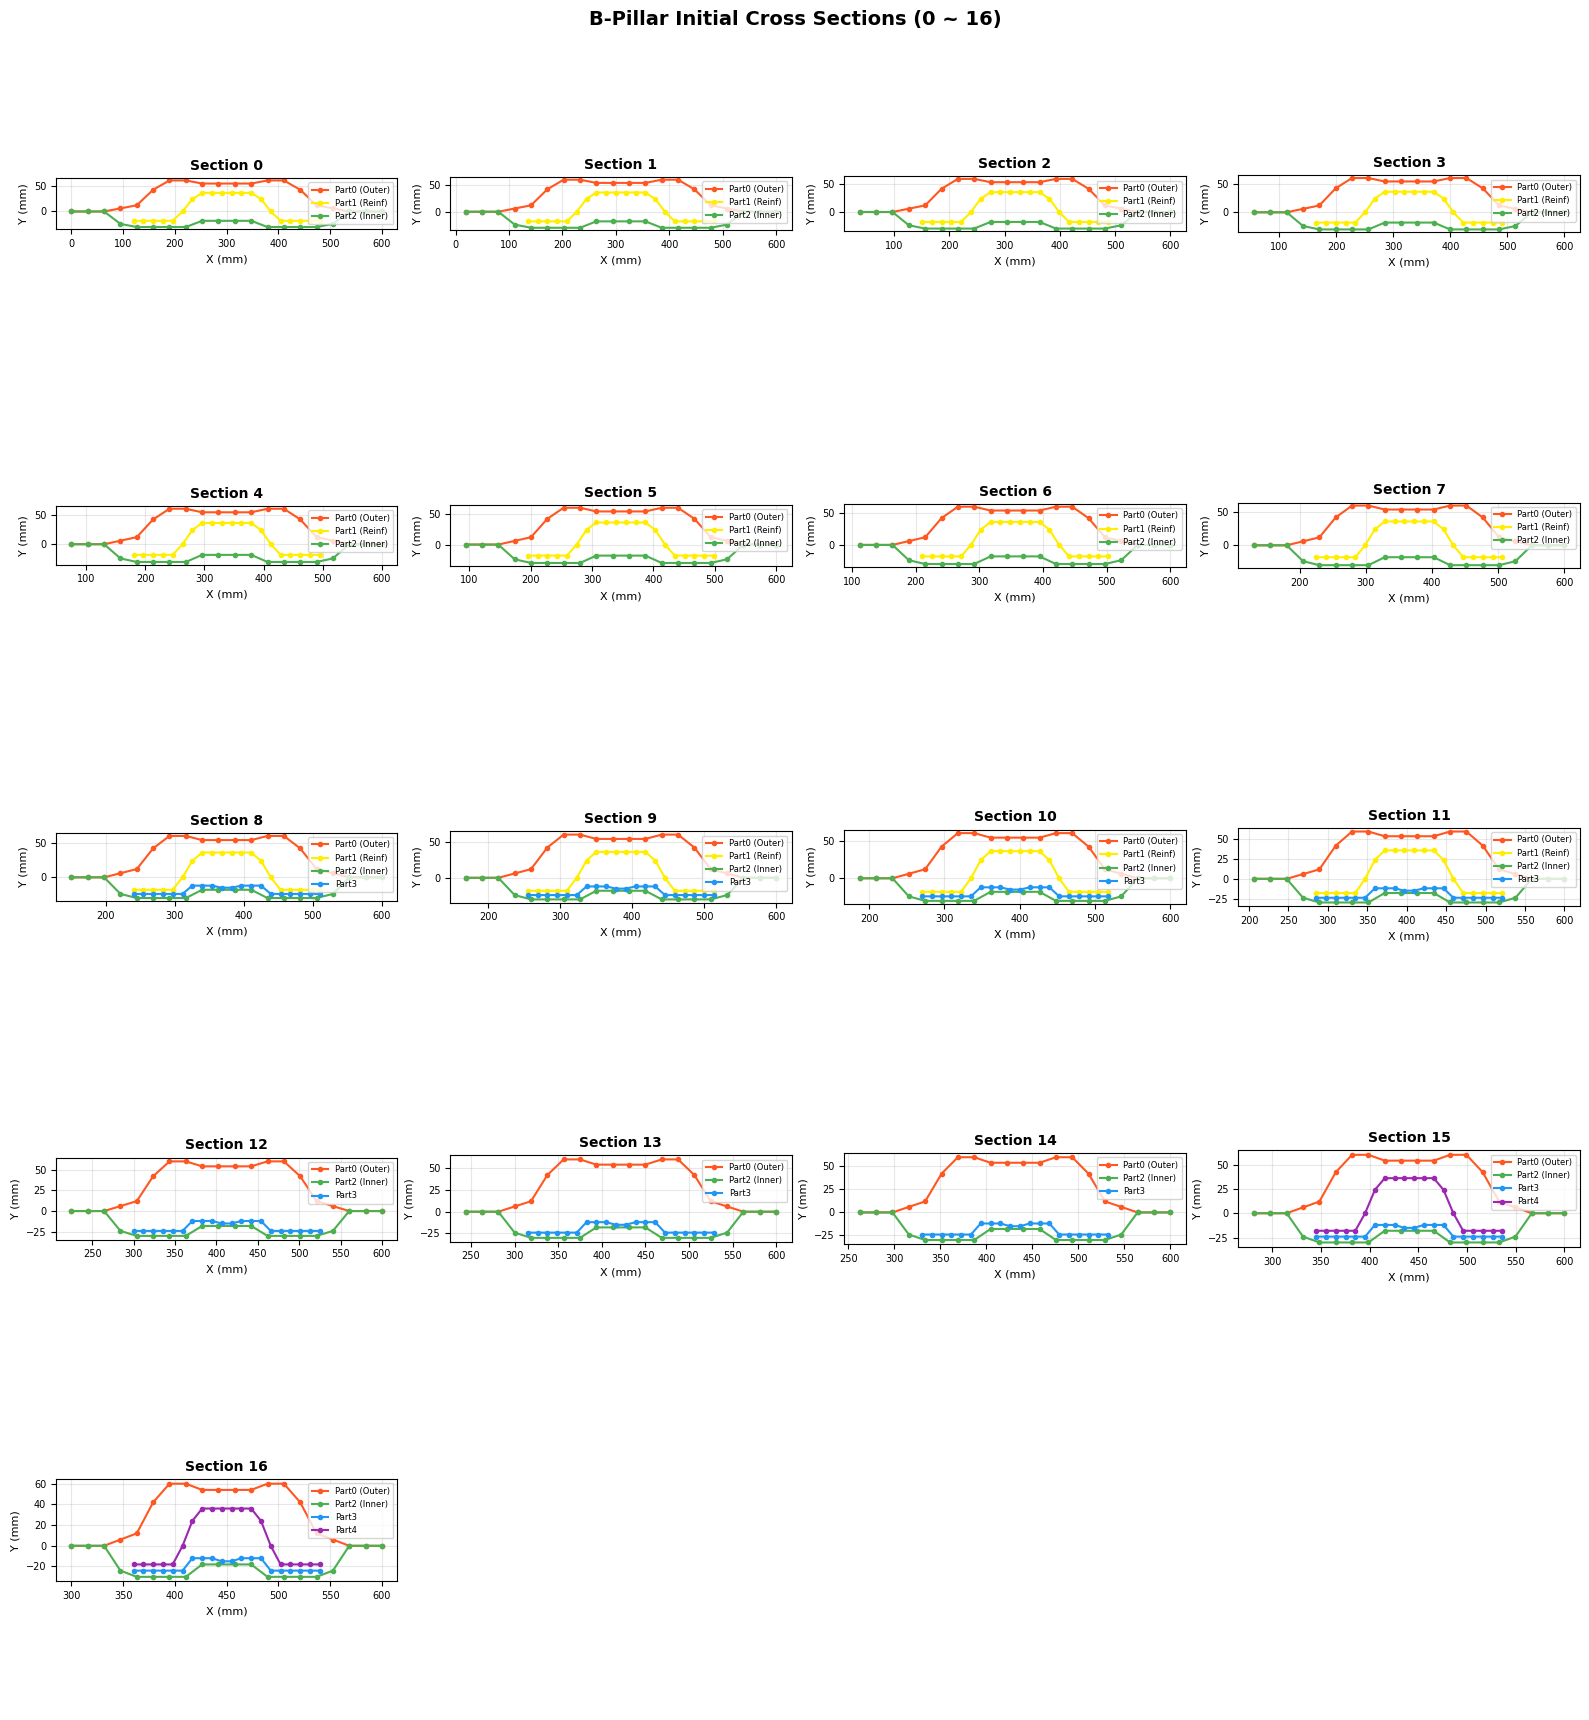

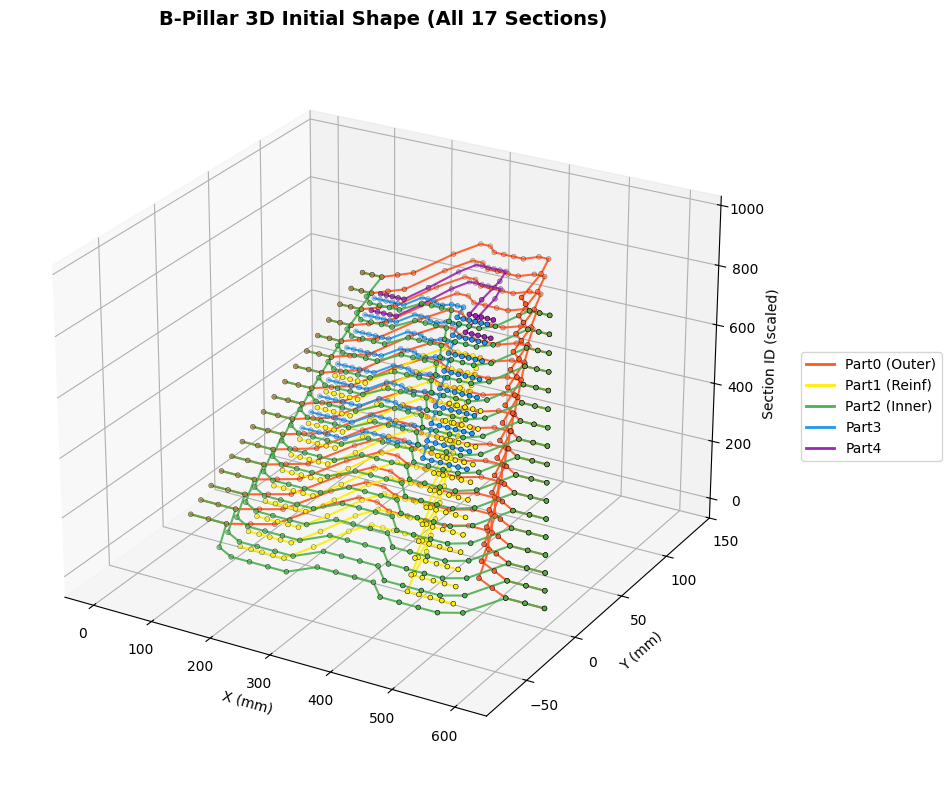

In [1]:
#!/usr/bin/env python
# coding: utf-8
"""
B-Pillar 초기 단면(Initial Section) 시각화
─────────────────────────────────────────
AI_design_v0.py의 노드 생성 로직(lower_section / upper_section 기반 보간)만 재현하여
학습 이전의 "초기 좌표"를 시각화한다.

출력:
  1) 섹션별 2D 단면 plot (17개, 하나의 figure에 subplot으로 배치)
  2) 17개 섹션을 종합한 3D plot (matplotlib, 회전/확대 가능한 인터랙티브 창)
  3) 17개 섹션을 종합한 3D plot (plotly, 브라우저에서 회전/확대/HTML로 저장)
"""

import math
import numpy as np
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════
# 초기 형상 정의 (AI_design_v0.py 그대로)
# ══════════════════════════════════════════════════════════════════

parts_in_sections = {
    0:  [0, 1, 2],
    1:  [0, 1, 2],
    2:  [0, 1, 2],
    3:  [0, 1, 2],
    4:  [0, 1, 2],
    5:  [0, 1, 2],
    6:  [0, 1, 2],
    7:  [0, 1, 2],
    8:  [0, 1, 2, 3],
    9:  [0, 1, 2, 3],
    10: [0, 1, 2, 3],
    11: [0, 1, 2, 3],
    12: [0, 2, 3],
    13: [0, 2, 3],
    14: [0, 2, 3],
    15: [0, 2, 3, 4],
    16: [0, 2, 3, 4],
}

lower_section = {
    0: [[  0.  ,   0.  ], [ 31.56,   0.  ], [ 63.12,   0.  ], [ 94.68,   6.  ],
        [126.24,  12.  ], [157.92,  42.  ], [189.48,  60.  ], [221.04,  60.  ],
        [252.6 ,  54.  ], [284.16,  54.  ], [315.84,  54.  ], [347.4 ,  54.  ],
        [378.96,  60.  ], [410.52,  60.  ], [442.08,  42.  ], [473.64,  12.  ],
        [505.32,   6.  ], [536.88,   0.  ], [568.44,   0.  ], [600.  ,   0.  ]],
    1: [[120.  , -18.  ], [138.96, -18.  ], [157.92, -18.  ], [176.76, -18.  ],
        [195.72, -18.  ], [214.8 ,   0.  ], [233.64,  24.  ], [252.6 ,  36.  ],
        [271.56,  36.  ], [290.52,  36.  ], [309.48,  36.  ], [328.44,  36.  ],
        [347.4 ,  36.  ], [366.36,  24.  ], [385.2 ,   0.  ], [404.16, -18.  ],
        [423.24, -18.  ], [442.08, -18.  ], [461.04, -18.  ], [480.  , -18.  ]],
    2: [[  0.  ,   0.  ], [ 31.56,   0.  ], [ 63.12,   0.  ], [ 94.68, -24.  ],
        [126.36, -30.  ], [157.92, -30.  ], [189.48, -30.  ], [221.04, -30.  ],
        [252.6 , -18.  ], [284.16, -18.  ], [315.84, -18.  ], [347.4 , -18.  ],
        [378.96, -30.  ], [410.52, -30.  ], [442.08, -30.  ], [473.64, -30.  ],
        [505.32, -24.  ], [536.88,   0.  ], [568.44,   0.  ], [600.  ,   0.  ]]
}

upper_section = {
    0: [[300.  ,   0.  ], [315.78,   0.  ], [331.56,   0.  ], [347.34,   6.  ],
        [363.12,  12.  ], [378.96,  42.  ], [394.74,  60.  ], [410.52,  60.  ],
        [426.3 ,  54.  ], [442.08,  54.  ], [457.92,  54.  ], [473.7 ,  54.  ],
        [489.48,  60.  ], [505.26,  60.  ], [521.04,  42.  ], [536.82,  12.  ],
        [552.66,   6.  ], [568.44,   0.  ], [584.22,   0.  ], [600.  ,   0.  ]],
    4: [[360.  , -18.  ], [369.48, -18.  ], [378.96, -18.  ], [388.38, -18.  ],
        [397.86, -18.  ], [407.4 ,   0.  ], [416.82,  24.  ], [426.3 ,  36.  ],
        [435.78,  36.  ], [445.26,  36.  ], [454.74,  36.  ], [464.22,  36.  ],
        [473.7 ,  36.  ], [483.18,  24.  ], [492.6 ,   0.  ], [502.08, -18.  ],
        [511.62, -18.  ], [521.04, -18.  ], [530.52, -18.  ], [540.  , -18.  ]],
    3: [[360.  , -24.  ], [369.48, -24.  ], [378.96, -24.  ], [388.38, -24.  ],
        [397.86, -24.  ], [407.4 , -24.  ], [416.82, -12.  ], [426.3 , -12.  ],
        [435.78, -12.  ], [445.26, -15.  ], [454.74, -15.  ], [464.22, -12.  ],
        [473.7 , -12.  ], [483.18, -12.  ], [492.6 , -24.  ], [502.08, -24.  ],
        [511.62, -24.  ], [521.04, -24.  ], [530.52, -24.  ], [540.  , -24.  ]],
    2: [[300.  ,   0.  ], [315.78,   0.  ], [331.56,   0.  ], [347.34, -24.  ],
        [363.18, -30.  ], [378.96, -30.  ], [394.74, -30.  ], [410.52, -30.  ],
        [426.3 , -18.  ], [442.08, -18.  ], [457.92, -18.  ], [473.7 , -18.  ],
        [489.48, -30.  ], [505.26, -30.  ], [521.04, -30.  ], [536.82, -30.  ],
        [552.66, -24.  ], [568.44,   0.  ], [584.22,   0.  ], [600.  ,   0.  ]]
}

num_sections = len(parts_in_sections)
num_nodes = 20

part_name = {0: 'Part0 (Outer)', 1: 'Part1 (Reinf)', 2: 'Part2 (Inner)', 3: 'Part3', 4: 'Part4'}
color_map = {0: '#FF5722', 1: '#FFEE00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}


def build_initial_coords():
    """AI_design_v0.py 노드 생성 로직(초기 좌표 부분)만 재현."""
    coords = {}  # (section, part) -> np.ndarray [num_nodes, 2]
    for section in range(num_sections):
        for part in parts_in_sections[section]:
            pts = np.zeros((num_nodes, 2), dtype=float)
            for i in range(num_nodes):
                if part in [0, 2]:
                    x_coord = i / 19 * (600.0 - (300 / (num_sections - 1)) * section) \
                              + (300 / (num_sections - 1)) * section
                else:
                    x_coord = i / 19 * (360 - (180 / (num_sections - 1)) * section) \
                              + 120 + (240 / (num_sections - 1)) * section

                if part == 1:
                    y_coord = upper_section[4][i][1]
                else:
                    y_coord = upper_section[part][i][1]

                if section == 16:
                    x_coord = upper_section[part][i][0]
                    y_coord = upper_section[part][i][1]
                elif section == 0:
                    x_coord = lower_section[part][i][0]
                    y_coord = lower_section[part][i][1]

                pts[i] = [x_coord, y_coord]
            coords[(section, part)] = pts
    return coords


coords = build_initial_coords()


# ══════════════════════════════════════════════════════════════════
# 1) 섹션별 2D 단면 plot
# ══════════════════════════════════════════════════════════════════

def plot_sections_2d(coords):
    n_cols = 4
    n_rows = math.ceil(num_sections / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = axes.flatten()

    for section in range(num_sections):
        ax = axes[section]
        for part in parts_in_sections[section]:
            pts = coords[(section, part)]
            ax.plot(pts[:, 0], pts[:, 1], '-o', ms=3,
                    color=color_map[part], label=part_name[part])
        ax.set_title(f'Section {section}', fontsize=10, fontweight='bold')
        ax.set_xlabel('X (mm)', fontsize=8)
        ax.set_ylabel('Y (mm)', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=6, loc='upper right')

    for k in range(num_sections, len(axes)):
        axes[k].axis('off')

    fig.suptitle('B-Pillar Initial Cross Sections (0 ~ 16)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig


# ══════════════════════════════════════════════════════════════════
# 2) 17개 섹션 종합 3D plot (matplotlib — 회전/확대 가능)
# ══════════════════════════════════════════════════════════════════

def plot_sections_3d_matplotlib(coords, z_coef=60.0):
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    for section in range(num_sections):
        z = section * z_coef
        for part in parts_in_sections[section]:
            pts = coords[(section, part)]
            ax.plot(pts[:, 0], pts[:, 1], zs=z, zdir='z',
                    color=color_map[part], linewidth=1.5, alpha=0.9)
            ax.scatter(pts[:, 0], pts[:, 1], zs=z, zdir='z',
                       c=color_map[part], s=12, edgecolors='k', linewidths=0.4)

    handles = [plt.Line2D([0], [0], color=color_map[p], lw=2, label=part_name[p])
               for p in color_map]
    ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.05, 0.5))

    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_zlabel('Section ID (scaled)')
    ax.set_title('B-Pillar 3D Initial Shape (All 17 Sections)', fontsize=14, fontweight='bold')
    ax.set_xlim(-50, 650)
    ax.set_ylim(-90, 150)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    return fig


# ══════════════════════════════════════════════════════════════════
# 3) 17개 섹션 종합 3D plot (plotly — 브라우저 인터랙티브, HTML 저장)
# ══════════════════════════════════════════════════════════════════

def plot_sections_3d_plotly(coords, z_coef=60.0, out_html='initial_section_3d.html'):
    import plotly.graph_objects as go

    fig = go.Figure()
    shown_legend = set()

    for section in range(num_sections):
        z = section * z_coef
        for part in parts_in_sections[section]:
            pts = coords[(section, part)]
            show_legend = part not in shown_legend
            shown_legend.add(part)
            fig.add_trace(go.Scatter3d(
                x=pts[:, 0], y=pts[:, 1], z=np.full(len(pts), z),
                mode='lines+markers',
                line=dict(color=color_map[part], width=4),
                marker=dict(size=3, color=color_map[part], line=dict(color='black', width=0.5)),
                name=part_name[part],
                legendgroup=part_name[part],
                showlegend=show_legend,
                hovertemplate=f'Section {section}, {part_name[part]}<br>x=%{{x:.1f}}, y=%{{y:.1f}}<extra></extra>',
            ))

    fig.update_layout(
        title='B-Pillar 3D Initial Shape (All 17 Sections) — Drag to rotate, scroll to zoom',
        scene=dict(
            xaxis_title='X (mm)',
            yaxis_title='Y (mm)',
            zaxis_title='Section ID (scaled)',
            aspectmode='data',
        ),
        width=1100, height=800,
    )
    fig.write_html(out_html)
    print(f"Saved interactive 3D plot to: {out_html}")
    return fig


if __name__ == "__main__":
    fig_2d = plot_sections_2d(coords)
    fig_3d_mpl = plot_sections_3d_matplotlib(coords)

    try:
        fig_3d_plotly = plot_sections_3d_plotly(coords)
        fig_3d_plotly.show()
    except ImportError:
        print("plotly가 설치되어 있지 않아 3번(plotly) plot은 건너뜁니다. `pip install plotly`로 설치 가능합니다.")

    plt.show()
